# 01. Exploratory Data Analysis

Этот ноутбук последовательно разбирает данные проекта по рекомендациям банковских продуктов и отвечает на три ключевых вопроса:

- как устроены данные и какова их временная структура;
- какие ограничения и риски задают качество данных;
- какие выводы из EDA напрямую влияют на постановку задачи, выбор признаков и способ валидации модели.

Главная цель EDA здесь не в том, чтобы собрать максимальное число графиков, а в том, чтобы подготовить обоснованную рекомендационную постановку для последующего моделирования.

## 1. Контекст задачи

Банк хранит ежемесячные снимки клиентского состояния: демографию, сегмент, активность, канал, доход и текущий продуктовый портфель. В прикладном сценарии система рекомендует клиенту новый продукт, а не описывает уже имеющийся набор продуктов.

В EDA данные рассматриваются как последовательность месячных состояний одного и того же клиента. Из этой структуры затем возникают time-based split, target-конструкция `t -> t+1` и ranking-метрики вместо обычной accuracy.


In [17]:
from __future__ import annotations

from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.build_dataset import load_modeling_month
from src.data.constants import CATEGORICAL_COLUMNS, NUMERIC_COLUMNS, PRODUCT_COLUMNS, PRODUCT_NAME_MAP
from src.utils.config import ProjectConfig

sns.set_theme(style='whitegrid', palette='deep')
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')

config = ProjectConfig()
EDA_DIR = PROJECT_ROOT / 'data' / 'eda_artifacts'

monthly_overview = pd.read_csv(EDA_DIR / 'monthly_overview.csv')
missing_profile = pd.read_csv(EDA_DIR / 'missing_profile.csv')
segment_profile = pd.read_csv(EDA_DIR / 'segment_profile.csv')
product_penetration = pd.read_csv(EDA_DIR / 'product_penetration.csv')
new_product_dynamics = pd.read_csv(EDA_DIR / 'new_product_dynamics.csv')
dataset_summary = json.loads((EDA_DIR / 'dataset_summary.json').read_text(encoding='utf-8'))

monthly_overview['snapshot_month'] = pd.to_datetime(monthly_overview['snapshot_month'])
missing_profile['snapshot_month'] = pd.to_datetime(missing_profile['snapshot_month'])
segment_profile['snapshot_month'] = pd.to_datetime(segment_profile['snapshot_month'])
product_penetration['snapshot_month'] = pd.to_datetime(product_penetration['snapshot_month'])
new_product_dynamics['snapshot_month'] = pd.to_datetime(new_product_dynamics['snapshot_month'])
new_product_dynamics['target_month'] = pd.to_datetime(new_product_dynamics['target_month'])

config

ProjectConfig(project_root=PosixPath('/home/what/praktika/practicum-sem4-praktika1'), random_state=42, raw_data_path=PosixPath('/home/what/praktika/practicum-sem4-praktika1/train_ver2.csv'), processed_dir=PosixPath('/home/what/praktika/practicum-sem4-praktika1/data/processed'), eda_dir=PosixPath('/home/what/praktika/practicum-sem4-praktika1/data/eda_artifacts'), models_dir=PosixPath('/home/what/praktika/practicum-sem4-praktika1/models'), mlruns_dir=PosixPath('/home/what/praktika/practicum-sem4-praktika1/mlruns'), mlflow_tracking_uri='sqlite:///mlruns/mlflow.db', mlflow_experiment='bank-product-recommendations', mlflow_registered_model_name='bank-product-recommendations-catboost', mlflow_model_alias='champion', primary_metric_name='val_map_at_3', train_months=('2015-02-28', '2015-03-28', '2015-04-28', '2015-05-28', '2015-06-28', '2015-07-28', '2015-08-28', '2015-09-28', '2015-10-28', '2015-11-28'), valid_months=('2015-12-28', '2016-01-28', '2016-02-28'), test_months=('2016-03-28', '2016

## 2. Что находится в данных

Таблица ниже фиксирует масштаб и структуру исходного набора: временной диапазон, число продуктовых признаков и основные группы клиентских полей.


In [18]:
source_summary = pd.DataFrame(
    {
        'aspect': [
            'Observation window',
            'Monthly snapshots',
            'Numeric client features',
            'Categorical client features',
            'Product flags',
            'Top products in the latest month',
        ],
        'value': [
            f"{monthly_overview['snapshot_month'].min().date()} -> {monthly_overview['snapshot_month'].max().date()}",
            monthly_overview['snapshot_month'].nunique(),
            len(NUMERIC_COLUMNS),
            len(CATEGORICAL_COLUMNS),
            len(PRODUCT_COLUMNS),
            ', '.join(item['product'] for item in dataset_summary['top_products_last_month']),
        ],
    }
)
source_summary

,aspect,value
0,Observation window,2015-01-28 -> 2016-05-28
1,Monthly snapshots,17
2,Numeric client features,8
3,Categorical client features,12
4,Product flags,24
5,Top products in the latest month,"ind_cco_fin_ult1, ind_recibo_ult1, ind_ctop_fin_ult1, ind_ecue_fin_ult1, ind_cno_fin_ult1"


Таблица показывает панельную природу данных: один и тот же бизнес-объект наблюдается во времени, а не один раз. Модельная постановка в такой задаче опирается на последовательность месячных состояний, а не только на статическое описание клиента.


## 3. Временная структура набора данных

Первый шаг EDA — понять, насколько данные стабильны по месяцам: меняется ли число клиентов, доля активных клиентов и насыщенность продуктового портфеля.

In [19]:
monthly_overview

,snapshot_month,rows,unique_clients,active_clients_share,avg_products_total,median_renta
0,2015-01-28,625457,625457,0.5318,1.7737,"102,609.9900"
1,2015-02-28,627394,627394,0.5352,1.7736,"102,556.4700"
2,2015-03-28,629209,629209,0.5384,1.7782,"102,490.7250"
3,2015-04-28,630367,630367,0.5418,1.7843,"102,445.9500"
4,2015-05-28,631957,631957,0.5453,1.7720,"102,407.8350"
5,2015-06-28,632110,632110,0.5495,1.7916,"102,351.9300"
6,2015-07-28,829817,829817,0.4290,1.3834,"102,092.7000"
7,2015-08-28,843201,843201,0.4300,1.3660,"101,733.3450"
8,2015-09-28,865440,865440,0.4286,1.3562,"101,489.3400"
9,2015-10-28,892251,892251,0.4233,1.3427,"101,489.3400"


Таблица подтверждает, что данные покрывают длинный временной интервал и включают крупные ежемесячные срезы. Уже по ней видно, что dataset нельзя считать набором независимых строк: каждый месяц является отдельным состоянием системы, и между этими состояниями есть собственная динамика.

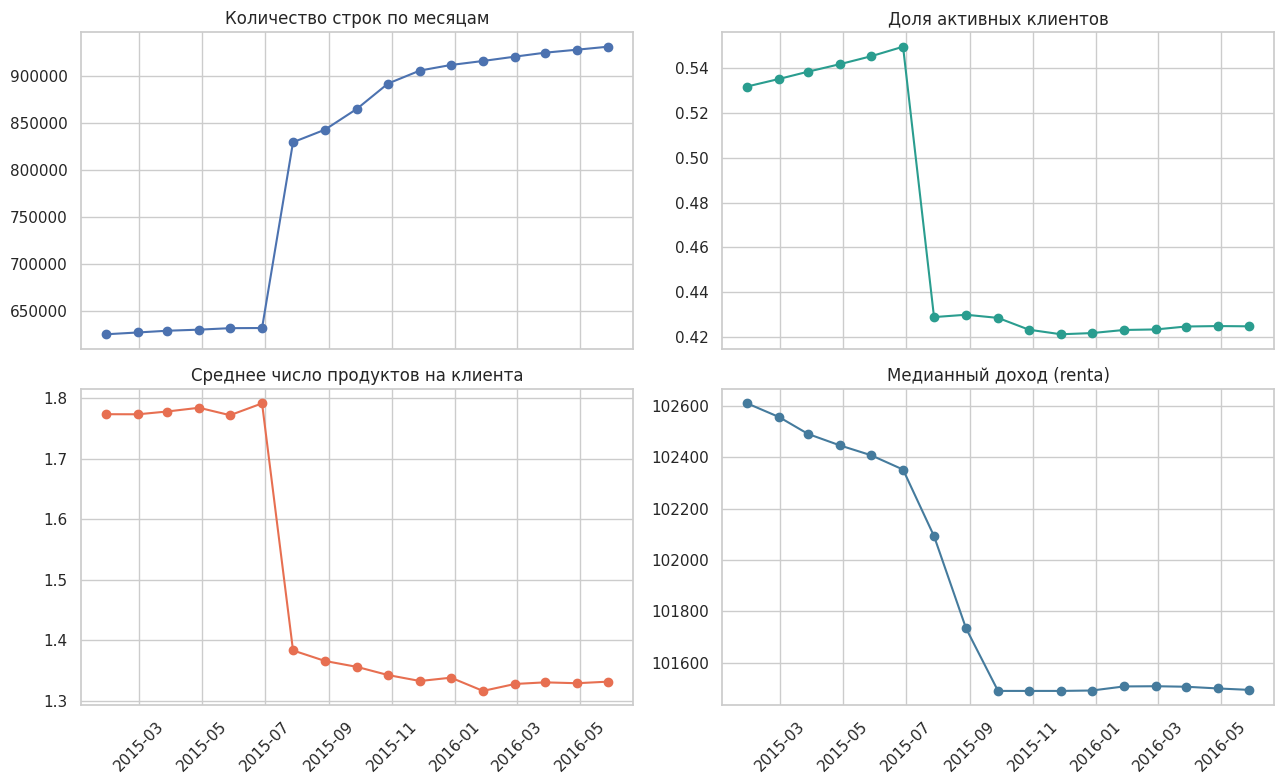

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
months = monthly_overview['snapshot_month']

axes[0, 0].plot(months, monthly_overview['rows'], marker='o')
axes[0, 0].set_title('Количество строк по месяцам')
axes[0, 0].tick_params(axis='x', rotation=45)

axes[0, 1].plot(months, monthly_overview['active_clients_share'], marker='o', color='#2a9d8f')
axes[0, 1].set_title('Доля активных клиентов')
axes[0, 1].tick_params(axis='x', rotation=45)

axes[1, 0].plot(months, monthly_overview['avg_products_total'], marker='o', color='#e76f51')
axes[1, 0].set_title('Среднее число продуктов на клиента')
axes[1, 0].tick_params(axis='x', rotation=45)

axes[1, 1].plot(months, monthly_overview['median_renta'], marker='o', color='#457b9d')
axes[1, 1].set_title('Медианный доход (renta)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Графики показывают, что объём данных по месяцам растёт, а сами клиентские срезы остаются достаточно плотными и информативными. Среднее число продуктов на клиента меняется не хаотично, а плавно, что говорит о стабильной структуре портфеля. Активность клиентов и медианный доход тоже демонстрируют временной контекст, поэтому случайное перемешивание строк здесь разрушило бы естественную хронологию данных.

## 4. Качество данных: пропуски и потенциально проблемные поля

Раздел ниже показывает, насколько надёжны клиентские признаки и в каких полях пропуски выражены сильнее всего.


In [21]:
latest_month = missing_profile['snapshot_month'].max()
latest_missing = (
    missing_profile.loc[missing_profile['snapshot_month'] == latest_month]
    .sort_values('missing_share', ascending=False)
    .reset_index(drop=True)
)
latest_missing

,snapshot_month,feature_name,missing_share
0,2016-05-28,renta,0.2459
1,2016-05-28,cod_prov,0.0043
2,2016-05-28,age,0.0000
3,2016-05-28,fecha_alta,0.0000
4,2016-05-28,nomprov,0.0000
5,2016-05-28,segmento,0.0000


Сводка по последнему месяцу показывает неравномерное распределение пропусков. Наиболее проблемным полем остаётся `renta`, тогда как остальные клиентские признаки имеют существенно меньшую долю missing values. В структуре данных именно доход формирует основной профиль пропусков.


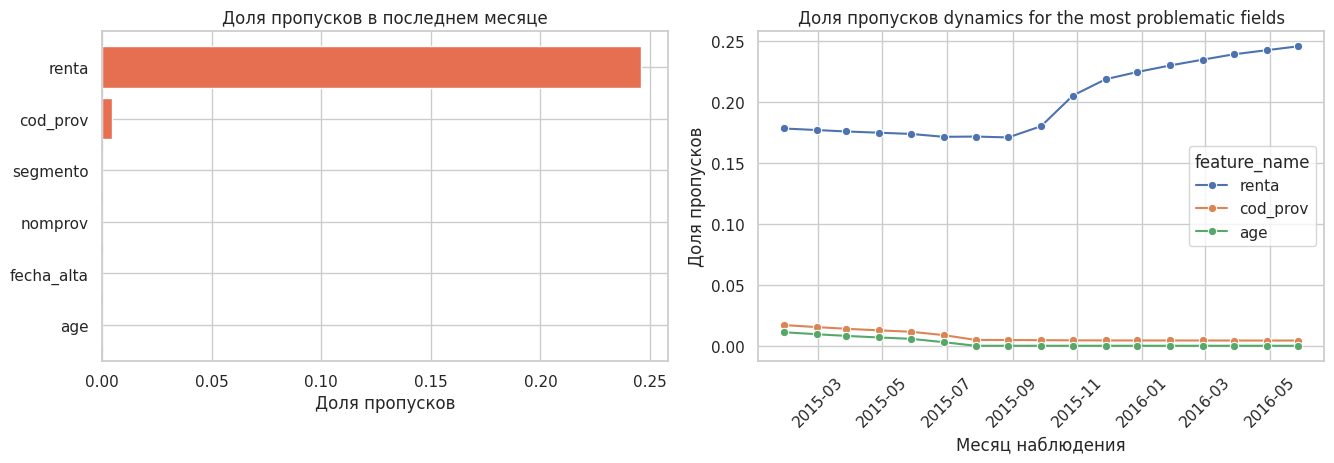

In [22]:
top_missing_features = (
    missing_profile.groupby('feature_name', as_index=False)['missing_share']
    .mean()
    .sort_values('missing_share', ascending=False)
    .head(3)['feature_name']
    .tolist()
)

latest_missing_plot = latest_missing.copy().sort_values('missing_share', ascending=True)
missing_trend_plot = missing_profile.loc[missing_profile['feature_name'].isin(top_missing_features)].copy()

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

axes[0].barh(latest_missing_plot['feature_name'], latest_missing_plot['missing_share'], color='#e76f51')
axes[0].set_title('Доля пропусков в последнем месяце')
axes[0].set_xlabel('Доля пропусков')
axes[0].set_ylabel('')

sns.lineplot(
    data=missing_trend_plot,
    x='snapshot_month',
    y='missing_share',
    hue='feature_name',
    marker='o',
    ax=axes[1],
)
axes[1].set_title('Доля пропусков dynamics for the most problematic fields')
axes[1].set_xlabel('Месяц наблюдения')
axes[1].set_ylabel('Доля пропусков')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


Левая диаграмма показывает профиль пропусков в последнем доступном месяце. Доля missing values по `renta` заметно выше остальных признаков и составляет около `24.6%`, тогда как у `cod_prov` она близка к `0.4%`, а у остальных показанных полей практически равна нулю.

Правая диаграмма показывает ту же картину во времени. `renta` остаётся стабильно самым проблемным признаком на всём горизонте наблюдений, со средней долей пропусков около `20.1%`. Для `cod_prov`, `age` и `fecha_alta` пропуски существенно ниже и со временем не формируют сопоставимой по масштабу проблемы. Следовательно, основной источник missing values в клиентских данных сосредоточен именно в поле дохода.


## 5. Структура текущего продуктового портфеля

Раздел ниже показывает, какие продукты широко распространены, а какие встречаются редко. Это распределение задаёт базовый фон для всей recommendation-задачи.


In [23]:
latest_penetration = (
    product_penetration.loc[product_penetration['snapshot_month'] == product_penetration['snapshot_month'].max()]
    .assign(product_name=lambda df: df['product'].map(PRODUCT_NAME_MAP))
    .sort_values('penetration_share', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
latest_penetration[['product', 'product_name', 'penetration_share']]

,product,product_name,penetration_share
0,ind_cco_fin_ult1,Current accounts,0.6029
1,ind_recibo_ult1,Direct debit,0.1214
2,ind_ctop_fin_ult1,Particular account,0.1080
3,ind_ecue_fin_ult1,E-account,0.0814
4,ind_cno_fin_ult1,Payroll account,0.0784
5,ind_nom_pens_ult1,Pensions payroll,0.0567
6,ind_nomina_ult1,Payroll,0.0519
7,ind_reca_fin_ult1,Taxes,0.0489
8,ind_tjcr_fin_ult1,Credit card,0.0374
9,ind_ctpp_fin_ult1,Particular plus account,0.0357


Таблица показывает сильную неоднородность продуктового портфеля. Часть продуктов имеет очень высокое проникновение, тогда как другие встречаются редко. При такой структуре массовые продукты естественно доминируют в popularity-based правилах, а редкие направления требуют более контекстного ранжирования.


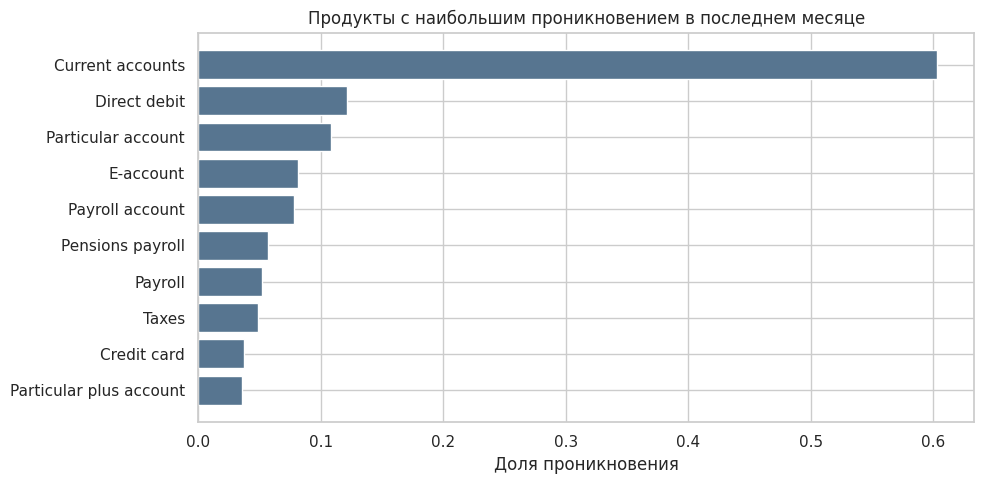

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = latest_penetration.sort_values('penetration_share', ascending=True)
ax.barh(plot_df['product_name'], plot_df['penetration_share'], color='#577590')
ax.set_title('Продукты с наибольшим проникновением в последнем месяце')
ax.set_xlabel('Доля проникновения')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

График показывает длинную асимметрию продуктового спроса: несколько продуктов образуют “тяжёлую голову” распределения, а остальные сильно уступают им по проникновению. Поэтому popularity-based baseline может быть сильным для массовых продуктов, но ограниченным для индивидуальных рекомендаций.


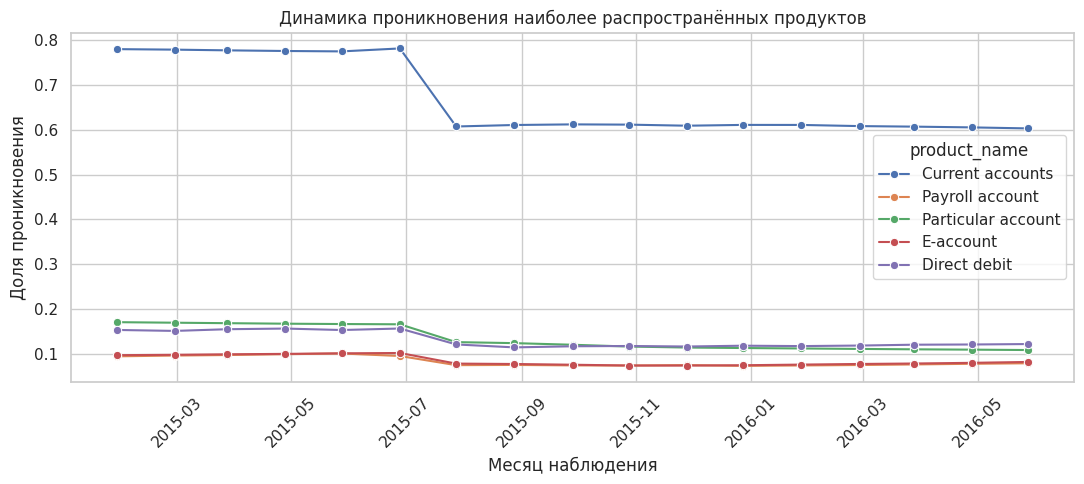

In [25]:
tracked_products = latest_penetration['product'].head(5).tolist()
trend_df = product_penetration.loc[product_penetration['product'].isin(tracked_products)].copy()
trend_df['product_name'] = trend_df['product'].map(PRODUCT_NAME_MAP)

fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(data=trend_df, x='snapshot_month', y='penetration_share', hue='product_name', marker='o', ax=ax)
ax.set_title('Динамика проникновения наиболее распространённых продуктов')
ax.set_xlabel('Месяц наблюдения')
ax.set_ylabel('Доля проникновения')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Динамика по самым распространённым продуктам показывает, что проникновение меняется во времени и не остаётся константой. Следовательно, даже для массовых продуктов статическое правило вида “всегда рекомендовать одно и то же” будет упрощением. Временной контекст действительно влияет на структуру портфеля, а значит должен быть отражён и в моделировании.

## 6. Как часто появляются новые продукты

Раздел ниже показывает не только текущий портфель, но и частоту новых подключений. Именно эти события позже становятся положительным target в modeling pipeline.


In [26]:
new_product_dynamics

,snapshot_month,target_month,new_products_total,share_with_new_product
0,2015-01-28,2015-02-28,31372,0.0380
1,2015-02-28,2015-03-28,31948,0.0402
2,2015-03-28,2015-04-28,30427,0.0405
3,2015-04-28,2015-05-28,26311,0.0336
4,2015-05-28,2015-06-28,41745,0.0527
5,2015-06-28,2015-07-28,33362,0.0413
6,2015-07-28,2015-08-28,29490,0.0293
7,2015-08-28,2015-09-28,35696,0.0338
8,2015-09-28,2015-10-28,39803,0.0372
9,2015-10-28,2015-11-28,35215,0.0314


Таблица показывает, что новые продукты появляются в каждом месяце, но доля клиентов с такими событиями остаётся сравнительно небольшой. Positive-класс в этой задаче редкий, поэтому дисбаланс присутствует уже на уровне исходных данных.


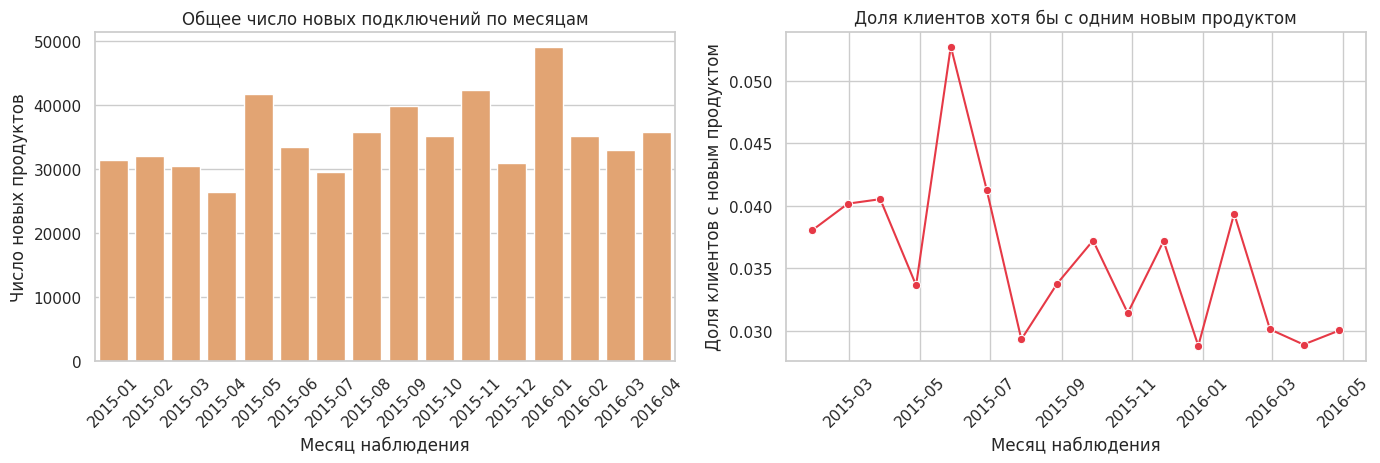

In [27]:
new_product_plot = new_product_dynamics.copy()
new_product_plot['snapshot_month_label'] = new_product_plot['snapshot_month'].dt.strftime('%Y-%m')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

sns.barplot(
    data=new_product_plot,
    x='snapshot_month_label',
    y='new_products_total',
    ax=axes[0],
    color='#f4a261',
)
axes[0].set_title('Общее число новых подключений по месяцам')
axes[0].set_xlabel('Месяц наблюдения')
axes[0].set_ylabel('Число новых продуктов')
axes[0].tick_params(axis='x', rotation=45)

sns.lineplot(
    data=new_product_plot,
    x='snapshot_month',
    y='share_with_new_product',
    marker='o',
    color='#e63946',
    ax=axes[1],
)
axes[1].set_title('Доля клиентов хотя бы с одним новым продуктом')
axes[1].set_xlabel('Месяц наблюдения')
axes[1].set_ylabel('Доля клиентов с новым продуктом')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


По обоим графикам видно, что новые подключения сохраняются на всём горизонте наблюдений, но остаются относительно редким явлением. Отсюда следуют три свойства задачи: target строится как переход `t -> t+1`, качество оценивается ranking-метриками типа `MAP@3`, а train требует аккуратной работы с негативными примерами.


In [28]:
modeling_months = sorted(path.stem for path in config.modeling_dir.glob('*.parquet'))
addition_rows = []
for month in modeling_months:
    monthly_df = load_modeling_month(config, month)
    target_columns = [f'target__{product}' for product in PRODUCT_COLUMNS]
    additions = monthly_df[target_columns].sum().rename(lambda col: col.replace('target__', ''))
    addition_rows.append(additions)

additions_by_product = (
    pd.DataFrame(addition_rows)
    .sum(axis=0)
    .rename_axis('product')
    .reset_index(name='new_product_events')
    .assign(product_name=lambda df: df['product'].map(PRODUCT_NAME_MAP))
    .sort_values('new_product_events', ascending=False)
    .reset_index(drop=True)
)
additions_by_product.head(12)

,product,new_product_events,product_name
0,ind_recibo_ult1,153146,Direct debit
1,ind_nom_pens_ult1,84709,Pensions payroll
2,ind_nomina_ult1,73753,Payroll
3,ind_tjcr_fin_ult1,69118,Credit card
4,ind_cco_fin_ult1,69103,Current accounts
5,ind_cno_fin_ult1,37098,Payroll account
6,ind_ecue_fin_ult1,26361,E-account
7,ind_dela_fin_ult1,12659,Long-term deposits
8,ind_reca_fin_ult1,9234,Taxes
9,ind_ctma_fin_ult1,6856,More particular account


Агрегация по целевым событиям показывает, что продукты сильно различаются не только по текущему проникновению, но и по частоте новых подключений. Часть продуктов имеет богатый обучающий сигнал, а часть остаётся редкой и сложной для предсказания.


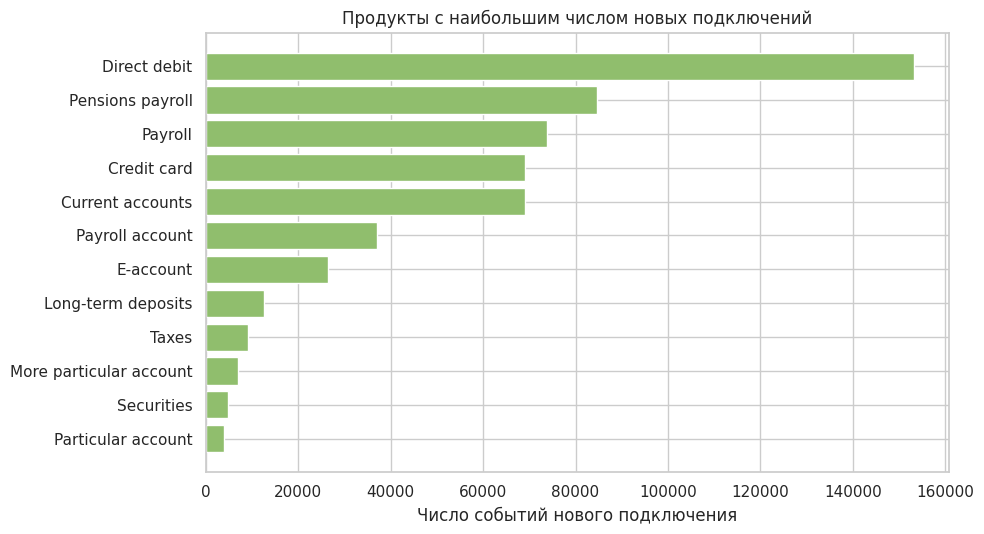

In [29]:
fig, ax = plt.subplots(figsize=(10, 5.5))
plot_df = additions_by_product.head(12).sort_values('new_product_events', ascending=True)
ax.barh(plot_df['product_name'], plot_df['new_product_events'], color='#90be6d')
ax.set_title('Продукты с наибольшим числом новых подключений')
ax.set_xlabel('Число событий нового подключения')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

График показывает, какие продуктовые направления чаще всего формируют recommendation target. Модель чаще наблюдает массовые сигналы новых подключений и заметно реже сталкивается с редкими продуктовыми сценариями. Это различие затем проявляется и в качестве по отдельным продуктам.


## 7. Клиентские сегменты

После общей динамики ниже рассматриваются бизнес-сегменты клиентов. Различия между сегментами по возрасту, доходу и насыщенности портфеля показывают, насколько сильным может быть сегментный сигнал в модели.


In [30]:
latest_segment_profile = (
    segment_profile.loc[segment_profile['snapshot_month'] == segment_profile['snapshot_month'].max()]
    .sort_values('clients', ascending=False)
    .assign(client_share=lambda df: df['clients'] / df['clients'].sum())
    .reset_index(drop=True)
)
latest_segment_profile[['segmento', 'clients', 'client_share', 'avg_age', 'avg_renta', 'avg_products_total']]

,segmento,clients,client_share,avg_age,avg_renta,avg_products_total
0,02 - PARTICULARES,542596,0.5825,49.2496,"140,835.9744",1.4210
1,03 - UNIVERSITARIO,346417,0.3719,24.3366,"117,441.0322",0.9388
2,01 - TOP,35415,0.0380,55.4472,"174,849.9793",4.0165
3,UNKNOWN,7025,0.0075,47.9100,"170,496.3074",0.2915


Таблица по последнему месяцу показывает, что сегменты различаются не только по размеру, но и по среднему возрасту, доходу и числу продуктов на клиента. Сегмент в этих данных несёт самостоятельный поведенческий сигнал, а не является формальным справочным полем.


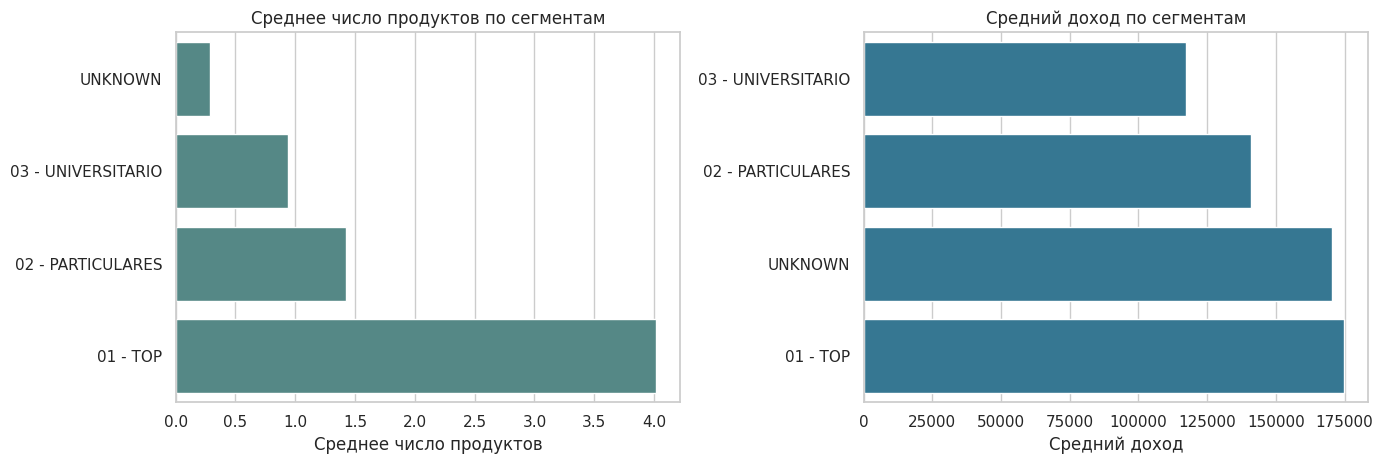

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
segment_order = latest_segment_profile.sort_values('avg_products_total', ascending=True)['segmento']

sns.barplot(data=latest_segment_profile, y='segmento', x='avg_products_total', order=segment_order, ax=axes[0], color='#4d908e')
axes[0].set_title('Среднее число продуктов по сегментам')
axes[0].set_xlabel('Среднее число продуктов')
axes[0].set_ylabel('')

income_order = latest_segment_profile.sort_values('avg_renta', ascending=True)['segmento']
sns.barplot(data=latest_segment_profile, y='segmento', x='avg_renta', order=income_order, ax=axes[1], color='#277da1')
axes[1].set_title('Средний доход по сегментам')
axes[1].set_xlabel('Средний доход')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

Графики подтверждают различия между сегментами. Более обеспеченные и зрелые сегменты в среднем имеют более насыщенный продуктовый портфель, тогда как другие сегменты остаются заметно “легче”. Поэтому segment-based baseline отражает реальную структуру данных, а сам сегмент естественно входит в основной набор признаков.


## 8. Итоговые выводы EDA

Exploratory analysis приводит к нескольким устойчивым выводам.

Во-первых, данные обладают выраженной временной структурой, поэтому случайное перемешивание строк недопустимо. Корректная постановка учитывает порядок месяцев и строит target на переходе между соседними snapshot'ами.

Во-вторых, набор данных сочетает в себе сильный табличный сигнал и реальные проблемы качества: пропуски, неоднородность признаков и различия между клиентскими сегментами. Наиболее заметный missing-pattern сосредоточен в `renta`.

В-третьих, текущий портфель и новые подключения распределены крайне неравномерно. Несколько продуктов доминируют по проникновению и по числу событий, тогда как другие остаются редкими. Поэтому задача естественным образом формулируется как recommendation / ranking, где модель выбирает наиболее релевантные новые продукты, а не просто угадывает самые массовые категории.

Наконец, EDA напрямую переходит в следующий этап проекта: построение modeling dataset, feature engineering и time-based сравнение baseline'ов и CatBoost-модели.
